# Enterprise Challenge Oracle & FIAP 2026 — HUBSUS360
## Sprint 3 — Disciplina: Statistical Methods for Data Science & Machine Learning
### Análise Exploratória de Dados (AED) — Painel Inteligente de Acesso Hospitalar e Perfil de Atendimento

**Turma:** 1TSCPF &nbsp;|&nbsp; **Projeto:** HUBSUS360 &nbsp;|&nbsp; **Grupo:** GP3L

**Integrantes do grupo (nomes em ordem alfabética):**
- `Guilherme Ladeira Correa Santos`
- `Lucas Amaral da Silva Barros`
- `Lucas Araujo Curci`
- `Lucas Luna Pimentel`
- `Pedro Henrique Moretti Aguiar`

---

### Objetivo desta entrega (Sprint 3 — Statistical Methods)

Conforme o enunciado da Sprint 3, o objetivo aqui é realizar uma **AED robusta** sobre o dataset unificado do desafio (`DATASET_AED_HUBSUS360.csv`), avaliando a **viabilidade de uso dos dados em uma futura modelagem preditiva** e documentando as **limitações inerentes à base**. O dataset já chega **unificado** (fontes SIH/SUS, CNES e CSV auxiliar já integradas pelo grupo em etapa anterior do pipeline), então este notebook foca em:

1. Dicionário de dados completo;
2. Distribuição das variáveis;
3. Métricas de localização e variabilidade;
4. Valores faltantes (missing) e outliers;
5. Relações entre variáveis;
6. Conclusão da AED com implicações para as próximas etapas (modelagem).

> ⚠️ **Cuidado central deste dataset:** cada linha **não** é uma internação nem um paciente — é um **perfil agregado** (competência × município de residência × hospital × diagnóstico × procedimento × faixa etária × sexo × raça/cor). Além disso, indicadores como `IEP_MUNICIPIO_MES`, `PC_INTERNACOES_ICSAP_MUNICIPIO_MES`, `PERMANENCIA_MEDIA_HOSPITAL_MES`, `PC_OBITOS_HOSPITAL_MES` e os leitos **se repetem em milhares de linhas**, pois foram calculados em outro nível de granularidade (município/mês ou hospital/mês). Todo o notebook segue as regras de manuseio combinadas pelo grupo para não somar/mediar essas colunas incorretamente.

## 1. Setup do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
CSV_PATH = "DATASET_AED_HUBSUS360.csv"  # ajuste o caminho se necessário

## 2. Carga dos dados com boas práticas de memória

O arquivo possui aproximadamente **6,87 milhões de linhas**. Para evitar estourar a memória RAM:

- Carregamos apenas as colunas necessárias com `usecols`;
- Usamos `dtype` otimizado: `category` para colunas de texto repetitivo (município, hospital, CID, procedimento, etc.), `int32`/`float32` para numéricos e `int8` para *flags*;
- Os **códigos** (`CD_MUNICIPIO_RESIDENCIA`, `CD_CNES`, `CD_CID10`, `CD_PROCEDIMENTO`) são carregados como `category`/texto para não perder zeros à esquerda;
- `DT_COMPETENCIA` é convertida para `datetime` já na leitura.

As colunas de texto livre `DS_DIAGNOSTICO` e `DS_PROCEDIMENTO` (alta cardinalidade, pouco úteis para as estatísticas desta sprint) e o identificador de linha `ID_PERFIL_INTERNACAO` são deixadas de fora da carga principal para economizar memória — elas não são necessárias para nenhuma das análises estatísticas solicitadas.

In [2]:
dtype_map = {
    # códigos -> mantidos como categoria/texto para não perder zeros à esquerda
    "CD_MUNICIPIO_RESIDENCIA": "category",
    "CD_CNES": "category",
    "CD_CID10": "category",
    "CD_PROCEDIMENTO": "category",
    "CD_CATEGORIA_CID10": "category",
    # dimensões descritivas (texto repetitivo) -> category
    "NM_MUNICIPIO": "category",
    "SG_UF": "category",
    "NM_REGIAO_SAUDE": "category",
    "NM_ESTABELECIMENTO": "category",
    "TP_ESTABELECIMENTO": "category",
    "ID_GRUPO_ICSAP": "category",
    "NM_GRUPO_ICSAP": "category",
    "CD_GRUPO_PROCEDIMENTO": "category",
    "NM_GRUPO_PROCEDIMENTO": "category",
    "TP_COMPLEXIDADE": "category",
    "DS_FAIXA_ETARIA": "category",
    "DS_SEXO": "category",
    "DS_RACA_COR": "category",
    # flags
    "FL_ICSAP": "int8",
    "FL_INDICADOR_HOSPITAL_CALCULAVEL": "int8",
    # métricas somáveis (nível perfil) -> numérico compacto
    "QT_REGISTROS_AIH": "int32",
    "QT_CONTINUIDADES_AIH": "int32",
    "VL_TOTAL_AIH": "float32",
    "QT_INTERNACOES": "int32",
    "QT_INTERNACOES_ELEGIVEIS_ICSAP": "int32",
    "QT_INTERNACOES_ICSAP": "int32",
    "VL_TOTAL_ICSAP": "float32",
    "VL_TOTAL_ELEGIVEL_IEP": "float32",
    "QT_DIAS_PERMANENCIA": "int32",
    "QT_SAIDAS_HOSPITALARES": "int32",
    "QT_OBITOS": "int32",
    # indicadores pré-calculados em outro nível (município/mês e hospital/mês) -> NÃO somar linha a linha
    "PC_INTERNACOES_ICSAP_MUNICIPIO_MES": "float32",
    "IEP_MUNICIPIO_MES": "float32",
    "QT_SAIDAS_HOSPITAL_MES": "int32",
    "PERMANENCIA_MEDIA_HOSPITAL_MES": "float32",
    "PC_OBITOS_HOSPITAL_MES": "float32",
    "QT_LEITOS_EXISTENTES_TOTAL": "int32",
    "QT_LEITOS_SUS_TOTAL": "int32",
}
usecols = list(dtype_map.keys()) + ["DT_COMPETENCIA"]

df = pd.read_csv(CSV_PATH, usecols=usecols, dtype=dtype_map, parse_dates=["DT_COMPETENCIA"])

print(f"Linhas (perfis): {len(df):,}".replace(",", "."))
print(f"Colunas carregadas: {df.shape[1]}")
print(f"Memória em uso: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Período: {df['DT_COMPETENCIA'].min().date()} a {df['DT_COMPETENCIA'].max().date()}  "
      f"({df['DT_COMPETENCIA'].dt.to_period('M').nunique()} meses)")
print(f"UF presente(s): {df['SG_UF'].unique().tolist()}")
print(f"Municípios distintos: {df['CD_MUNICIPIO_RESIDENCIA'].nunique()}")
print(f"Hospitais (CNES) distintos: {df['CD_CNES'].nunique()}")

Linhas (perfis): 6.870.571
Colunas carregadas: 39
Memória em uso: 0.74 GB
Período: 2023-01-01 a 2025-12-01  (36 meses)
UF presente(s): ['SP']
Municípios distintos: 645
Hospitais (CNES) distintos: 657


## 3. Dicionário de dados

O dicionário abaixo documenta, para **cada coluna** do dataset unificado: o **grão** em que ela é válida (perfil, município/mês ou hospital/mês), se ela **pode ser somada linha a linha**, e observações sobre nulos esperados. Ele foi construído com base nas regras de manuseio definidas pelo grupo na etapa de engenharia de dados e serve como referência para qualquer novo integrante do time.

In [3]:
dicionario = [
    ("DT_COMPETENCIA", "data", "perfil", "não aplicável", "Mês de processamento/competência do dado. Chave de tempo."),
    ("CD_MUNICIPIO_RESIDENCIA", "texto (código)", "perfil", "não aplicável", "Código IBGE do município de RESIDÊNCIA do paciente (não é o município do hospital)."),
    ("NM_MUNICIPIO", "categórico", "perfil", "não aplicável", "Nome do município de residência."),
    ("SG_UF", "categórico", "perfil", "não aplicável", "UF do município de residência (dataset restrito a SP)."),
    ("NM_REGIAO_SAUDE", "categórico", "perfil", "não aplicável", "Região de saúde do município de residência."),
    ("CD_CNES", "texto (código)", "perfil", "não aplicável", "Código CNES do estabelecimento hospitalar."),
    ("NM_ESTABELECIMENTO", "categórico", "perfil", "não aplicável", "Nome do hospital. Pode conter 'ESTABELECIMENTO NAO LOCALIZADO NA REFERENCIA CNES DE 12/2025' (56 casos históricos válidos)."),
    ("TP_ESTABELECIMENTO", "categórico", "perfil", "não aplicável", "Tipo do estabelecimento (hospital geral, especializado, pronto-socorro, etc.)."),
    ("CD_CID10", "texto (código)", "perfil", "não aplicável", "Código CID-10 do diagnóstico."),
    ("CD_CATEGORIA_CID10", "categórico", "perfil", "não aplicável", "Categoria (3 dígitos) do CID-10."),
    ("DS_DIAGNOSTICO", "texto livre", "perfil", "não aplicável", "Descrição do diagnóstico (não carregada nesta AED por ser alta cardinalidade / baixo uso estatístico)."),
    ("ID_GRUPO_ICSAP", "categórico", "perfil", "esperado quando FL_ICSAP=0", "Identificador do grupo ICSAP. Nulo quando o diagnóstico não é ICSAP — NÃO preencher com 0/valor artificial."),
    ("NM_GRUPO_ICSAP", "categórico", "perfil", "esperado quando FL_ICSAP=0", "Nome do grupo ICSAP. Mesmo comportamento de nulo que ID_GRUPO_ICSAP."),
    ("FL_ICSAP", "flag (0/1)", "perfil", "não aplicável", "1 = diagnóstico pertence à lista ICSAP. Identifica a LINHA (perfil), não conta internações."),
    ("CD_PROCEDIMENTO", "texto (código)", "perfil", "não aplicável", "Código do procedimento realizado."),
    ("DS_PROCEDIMENTO", "texto livre", "perfil", "não aplicável", "Descrição do procedimento (não carregada nesta AED)."),
    ("CD_GRUPO_PROCEDIMENTO", "categórico", "perfil", "não aplicável", "Código do grupo de procedimento (SIGTAP)."),
    ("NM_GRUPO_PROCEDIMENTO", "categórico", "perfil", "não aplicável", "Nome do grupo de procedimento."),
    ("TP_COMPLEXIDADE", "categórico", "perfil", "não aplicável", "Complexidade do procedimento (baixa/média/alta)."),
    ("DS_FAIXA_ETARIA", "categórico", "perfil", "não aplicável", "Faixa etária do paciente. Inclui a categoria 'IDADE NAO INFORMADA', que deve ser preservada."),
    ("DS_SEXO", "categórico", "perfil", "não aplicável", "Sexo do paciente."),
    ("DS_RACA_COR", "categórico", "perfil", "não aplicável", "Raça/cor do paciente."),
    ("QT_REGISTROS_AIH", "numérico (soma)", "perfil", "não esperado", "Total de registros de AIH (inclui novas internações + continuidades)."),
    ("QT_CONTINUIDADES_AIH", "numérico (soma)", "perfil", "não esperado", "Registros de continuidade de uma internação já existente (não é nova internação)."),
    ("VL_TOTAL_AIH", "numérico (soma)", "perfil", "não esperado", "Valor de todos os registros de AIH, incluindo continuidades."),
    ("QT_INTERNACOES", "numérico (soma)", "perfil", "não esperado", "**Métrica correta para contar internações** (somente novas internações)."),
    ("QT_INTERNACOES_ELEGIVEIS_ICSAP", "numérico (soma)", "perfil", "não esperado", "Internações elegíveis à classificação ICSAP."),
    ("QT_INTERNACOES_ICSAP", "numérico (soma)", "perfil", "não esperado", "Internações classificadas como ICSAP."),
    ("VL_TOTAL_ICSAP", "numérico (soma)", "perfil", "não esperado", "Valor total das internações ICSAP."),
    ("VL_TOTAL_ELEGIVEL_IEP", "numérico (soma)", "perfil", "não esperado", "Valor total elegível para cálculo do IEP."),
    ("QT_DIAS_PERMANENCIA", "numérico (soma)", "perfil", "não esperado", "Dias de permanência hospitalar."),
    ("QT_SAIDAS_HOSPITALARES", "numérico (soma)", "perfil", "não esperado", "Saídas hospitalares (altas, óbitos, transferências)."),
    ("QT_OBITOS", "numérico (soma)", "perfil", "não esperado", "Óbitos hospitalares."),
    ("PC_INTERNACOES_ICSAP_MUNICIPIO_MES", "numérico (pré-calculado)", "**município/mês**", "não esperado", "Repetido em todas as linhas do mesmo município/mês. NÃO somar/mediar direto — recalcular como soma(ICSAP)/soma(elegíveis)×100."),
    ("IEP_MUNICIPIO_MES", "numérico (pré-calculado)", "**município/mês**", "não esperado", "Índice experimental (não oficial do SUS). Repetido por município/mês. Recalcular via soma(VL_ICSAP)/soma(VL_ELEGIVEL_IEP)."),
    ("QT_SAIDAS_HOSPITAL_MES", "numérico (pré-calculado)", "**hospital/mês**", "não esperado", "Repetido por hospital/mês."),
    ("FL_INDICADOR_HOSPITAL_CALCULAVEL", "flag (0/1)", "hospital/mês", "não aplicável", "0 = hospital sem saída registrada no mês -> indicadores de permanência/mortalidade não devem ser calculados."),
    ("PERMANENCIA_MEDIA_HOSPITAL_MES", "numérico (pré-calculado)", "**hospital/mês**", "esperado quando FL_INDICADOR_HOSPITAL_CALCULAVEL=0", "Repetido por hospital/mês. Nulo válido (243 combinações). Recalcular via soma(dias)/soma(saídas)."),
    ("PC_OBITOS_HOSPITAL_MES", "numérico (pré-calculado)", "**hospital/mês**", "esperado quando FL_INDICADOR_HOSPITAL_CALCULAVEL=0", "Mesma lógica de nulo/recálculo de PERMANENCIA_MEDIA_HOSPITAL_MES."),
    ("QT_LEITOS_EXISTENTES_TOTAL", "numérico (pré-calculado)", "**hospital/mês**", "não esperado", "Capacidade cadastrada no CNES no mês. NÃO representa ocupação/disponibilidade em tempo real. Repetido por hospital/mês — deduplicar antes de analisar."),
    ("QT_LEITOS_SUS_TOTAL", "numérico (pré-calculado)", "**hospital/mês**", "não esperado", "Mesma lógica de QT_LEITOS_EXISTENTES_TOTAL, restrito a leitos SUS."),
]

df_dicionario = pd.DataFrame(dicionario, columns=["Coluna", "Tipo", "Grão válido", "Nulos esperados", "Descrição / regra de uso"])
df_dicionario

,Coluna,Tipo,Grão válido,Nulos esperados,Descrição / regra de uso
0,DT_COMPETENCIA,data,perfil,não aplicável,Mês de processamento/competência do dado. Chave de tempo.
1,CD_MUNICIPIO_RESIDENCIA,texto (código),perfil,não aplicável,Código IBGE do município de RESIDÊNCIA do paciente (não é o município do hospital).
2,NM_MUNICIPIO,categórico,perfil,não aplicável,Nome do município de residência.
3,SG_UF,categórico,perfil,não aplicável,UF do município de residência (dataset restrito a SP).
4,NM_REGIAO_SAUDE,categórico,perfil,não aplicável,Região de saúde do município de residência.
5,CD_CNES,texto (código),perfil,não aplicável,Código CNES do estabelecimento hospitalar.
6,NM_ESTABELECIMENTO,categórico,perfil,não aplicável,Nome do hospital. Pode conter 'ESTABELECIMENTO NAO LOCALIZADO NA REFERENCIA CNES DE 12/2025' (56 casos históricos válidos).
7,TP_ESTABELECIMENTO,categórico,perfil,não aplicável,"Tipo do estabelecimento (hospital geral, especializado, pronto-socorro, etc.)."
8,CD_CID10,texto (código),perfil,não aplicável,Código CID-10 do diagnóstico.
9,CD_CATEGORIA_CID10,categórico,perfil,não aplicável,Categoria (3 dígitos) do CID-10.


## 4. Granularidade dos dados e construção das visões analíticas

Como o dataset mistura três granularidades diferentes na mesma tabela, construímos **três visões** antes de qualquer estatística:

| Visão | Chave | Uso |
|---|---|---|
| `df` (perfil) | 1 linha por perfil agregado | Distribuição de diagnósticos, procedimentos, valores e permanência por atendimento |
| `mun` (município/mês) | `DT_COMPETENCIA + CD_MUNICIPIO_RESIDENCIA` | IEP, % ICSAP, volume de internações por município |
| `hosp` (hospital/mês) | `DT_COMPETENCIA + CD_CNES` | Permanência média, mortalidade e leitos por hospital |

Em `mun` e `hosp`, as colunas somáveis são **recalculadas a partir da soma dos perfis** (nunca somando o indicador pré-calculado), e as colunas pré-calculadas (`IEP_MUNICIPIO_MES`, `PERMANENCIA_MEDIA_HOSPITAL_MES`, leitos, etc.) são **deduplicadas com `first()`** dentro de cada grupo, já que são constantes naquele grão.

In [4]:
# ---------- Visão MUNICÍPIO / MÊS ----------
sum_cols_mun = [
    "QT_REGISTROS_AIH", "QT_CONTINUIDADES_AIH", "VL_TOTAL_AIH", "QT_INTERNACOES",
    "QT_INTERNACOES_ELEGIVEIS_ICSAP", "QT_INTERNACOES_ICSAP", "VL_TOTAL_ICSAP", "VL_TOTAL_ELEGIVEL_IEP",
]
mun_sum = (
    df.groupby(["DT_COMPETENCIA", "CD_MUNICIPIO_RESIDENCIA"], observed=True)[sum_cols_mun]
    .sum()
    .reset_index()
)
mun_meta = (
    df.groupby(["DT_COMPETENCIA", "CD_MUNICIPIO_RESIDENCIA"], observed=True)
    .agg(
        NM_MUNICIPIO=("NM_MUNICIPIO", "first"),
        SG_UF=("SG_UF", "first"),
        NM_REGIAO_SAUDE=("NM_REGIAO_SAUDE", "first"),
        PC_INTERNACOES_ICSAP_MUNICIPIO_MES=("PC_INTERNACOES_ICSAP_MUNICIPIO_MES", "first"),
        IEP_MUNICIPIO_MES=("IEP_MUNICIPIO_MES", "first"),
    )
    .reset_index()
)
mun = mun_sum.merge(mun_meta, on=["DT_COMPETENCIA", "CD_MUNICIPIO_RESIDENCIA"])

# Recálculo correto (regras 5 e 6 do grupo)
mun["PC_ICSAP_RECALC"] = np.where(
    mun["QT_INTERNACOES_ELEGIVEIS_ICSAP"] > 0,
    mun["QT_INTERNACOES_ICSAP"] / mun["QT_INTERNACOES_ELEGIVEIS_ICSAP"] * 100,
    np.nan,
)
mun["IEP_RECALC"] = np.where(
    mun["VL_TOTAL_ELEGIVEL_IEP"] > 0,
    100 - (mun["VL_TOTAL_ICSAP"] / mun["VL_TOTAL_ELEGIVEL_IEP"] * 100),
    np.nan,
)

print(f"Visão município/mês: {mun.shape[0]:,} combinações município×mês, {mun['CD_MUNICIPIO_RESIDENCIA'].nunique()} municípios distintos".replace(",", "."))

# validação: recálculo deve bater com o indicador pré-calculado fornecido (mesmo grão)
diff_pc = (mun["PC_ICSAP_RECALC"] - mun["PC_INTERNACOES_ICSAP_MUNICIPIO_MES"]).abs()
diff_iep = (mun["IEP_RECALC"] - mun["IEP_MUNICIPIO_MES"]).abs()
print(f"Validação PC_ICSAP recalculado vs. fornecido -> diferença média: {diff_pc.mean():.4f} p.p. (máx {diff_pc.max():.4f})")
print(f"Validação IEP recalculado vs. fornecido       -> diferença média: {diff_iep.mean():.4f} p.p. (máx {diff_iep.max():.4f})")
print("(diferenças residuais na 3ª/4ª casa decimal são esperadas — arredondamento de float32)")

Visão município/mês: 23.220 combinações município×mês. 645 municípios distintos
Validação PC_ICSAP recalculado vs. fornecido -> diferença média: 0.0023 p.p. (máx 0.0050)
Validação IEP recalculado vs. fornecido       -> diferença média: 0.0024 p.p. (máx 0.0050)
(diferenças residuais na 3ª/4ª casa decimal são esperadas — arredondamento de float32)


In [5]:
# ---------- Visão HOSPITAL / MÊS ----------
sum_cols_hosp = ["QT_DIAS_PERMANENCIA", "QT_SAIDAS_HOSPITALARES", "QT_OBITOS", "QT_INTERNACOES"]
hosp_sum = (
    df.groupby(["DT_COMPETENCIA", "CD_CNES"], observed=True)[sum_cols_hosp]
    .sum()
    .reset_index()
)
hosp_meta = (
    df.groupby(["DT_COMPETENCIA", "CD_CNES"], observed=True)
    .agg(
        NM_ESTABELECIMENTO=("NM_ESTABELECIMENTO", "first"),
        TP_ESTABELECIMENTO=("TP_ESTABELECIMENTO", "first"),
        FL_INDICADOR_HOSPITAL_CALCULAVEL=("FL_INDICADOR_HOSPITAL_CALCULAVEL", "first"),
        PERMANENCIA_MEDIA_HOSPITAL_MES=("PERMANENCIA_MEDIA_HOSPITAL_MES", "first"),
        PC_OBITOS_HOSPITAL_MES=("PC_OBITOS_HOSPITAL_MES", "first"),
        QT_LEITOS_EXISTENTES_TOTAL=("QT_LEITOS_EXISTENTES_TOTAL", "first"),
        QT_LEITOS_SUS_TOTAL=("QT_LEITOS_SUS_TOTAL", "first"),
    )
    .reset_index()
)
hosp = hosp_sum.merge(hosp_meta, on=["DT_COMPETENCIA", "CD_CNES"])

# Recálculo correto (regra 9 do grupo)
hosp["PERMANENCIA_MEDIA_RECALC"] = np.where(
    hosp["QT_SAIDAS_HOSPITALARES"] > 0,
    hosp["QT_DIAS_PERMANENCIA"] / hosp["QT_SAIDAS_HOSPITALARES"],
    np.nan,
)
hosp["MORTALIDADE_RECALC"] = np.where(
    hosp["QT_SAIDAS_HOSPITALARES"] > 0,
    hosp["QT_OBITOS"] / hosp["QT_SAIDAS_HOSPITALARES"] * 100,
    np.nan,
)

print(f"Visão hospital/mês: {hosp.shape[0]:,} combinações hospital×mês, {hosp['CD_CNES'].nunique()} hospitais (CNES) distintos".replace(",", "."))

n_sem_saida = (hosp["FL_INDICADOR_HOSPITAL_CALCULAVEL"] == 0).sum()
print(f"Combinações hospital/mês sem saída registrada (FL_INDICADOR_HOSPITAL_CALCULAVEL=0): {n_sem_saida}")
print(f"Nulos em PERMANENCIA_MEDIA_HOSPITAL_MES: {hosp['PERMANENCIA_MEDIA_HOSPITAL_MES'].isna().sum()}  |  "
      f"Nulos em PC_OBITOS_HOSPITAL_MES: {hosp['PC_OBITOS_HOSPITAL_MES'].isna().sum()}")
print("-> Os 243 casos batem exatamente com o valor documentado nas regras do grupo, confirmando que os nulos são legítimos e não devem ser preenchidos com zero.")

diff_perm = (hosp["PERMANENCIA_MEDIA_RECALC"] - hosp["PERMANENCIA_MEDIA_HOSPITAL_MES"]).abs()
print(f"Validação permanência média recalculada vs. fornecida -> diferença média: {diff_perm.mean():.4f} dias (máx {diff_perm.max():.4f})")

Visão hospital/mês: 22.224 combinações hospital×mês. 657 hospitais (CNES) distintos
Combinações hospital/mês sem saída registrada (FL_INDICADOR_HOSPITAL_CALCULAVEL=0): 243
Nulos em PERMANENCIA_MEDIA_HOSPITAL_MES: 243  |  Nulos em PC_OBITOS_HOSPITAL_MES: 243
-> Os 243 casos batem exatamente com o valor documentado nas regras do grupo, confirmando que os nulos são legítimos e não devem ser preenchidos com zero.
Validação permanência média recalculada vs. fornecida -> diferença média: 0.0022 dias (máx 0.0050)


## 5. Estatísticas descritivas corretas (cuidado com a granularidade)

Antes de qualquer estatística, evidenciamos a **armadilha nº 1** deste dataset: contar linhas não é o mesmo que contar internações, porque cada linha é um perfil agregado, não um evento.

In [6]:
n_linhas = len(df)
n_internacoes = int(df["QT_INTERNACOES"].sum())
n_registros_aih = int(df["QT_REGISTROS_AIH"].sum())
n_continuidades = int(df["QT_CONTINUIDADES_AIH"].sum())

print(f"len(df)                        = {n_linhas:>10,} <- ERRADO como 'número de internações' (é o nº de PERFIS agregados)".replace(",", "."))
print(f"QT_INTERNACOES.sum()           = {n_internacoes:>10,} <- CORRETO (somente novas internações)".replace(",", "."))
print(f"QT_REGISTROS_AIH.sum()         = {n_registros_aih:>10,} (internações + continuidades)".replace(",", "."))
print(f"QT_CONTINUIDADES_AIH.sum()     = {n_continuidades:>10,}".replace(",", "."))
print(f"\nChecagem de consistência: internações + continuidades == registros de AIH? "
      f"{n_internacoes + n_continuidades == n_registros_aih}")

len(df)                        =  6.870.571 <- ERRADO como 'número de internações' (é o nº de PERFIS agregados)
QT_INTERNACOES.sum()           =  8.245.697 <- CORRETO (somente novas internações)
QT_REGISTROS_AIH.sum()         =  8.409.047 (internações + continuidades)
QT_CONTINUIDADES_AIH.sum()     =    163.350

Checagem de consistência: internações + continuidades == registros de AIH? True


In [7]:
# Estatísticas de localização e variabilidade — NÍVEL PERFIL (variáveis somáveis)
desc_perfil = df[["VL_TOTAL_AIH", "QT_DIAS_PERMANENCIA", "QT_INTERNACOES"]].describe().T
desc_perfil["mediana"] = df[["VL_TOTAL_AIH", "QT_DIAS_PERMANENCIA", "QT_INTERNACOES"]].median()
desc_perfil["CV (%)"] = (desc_perfil["std"] / desc_perfil["mean"] * 100).round(1)
desc_perfil

,count,mean,std,min,25%,50%,75%,max,mediana,CV (%)
VL_TOTAL_AIH,"6,870,571.00","2,160.60","5,348.03",0.00,364.72,736.95,"1,710.91","509,798.00",736.95,247.50
QT_DIAS_PERMANENCIA,"6,870,571.00",6.26,12.32,0.00,1.00,3.00,7.00,"1,870.00",3.00,196.80
QT_INTERNACOES,"6,870,571.00",1.20,1.25,0.00,1.00,1.00,1.00,117.00,1.00,104.20


In [8]:
# Estatísticas — NÍVEL MUNICÍPIO/MÊS (indicadores recalculados corretamente)
desc_mun = mun[["PC_ICSAP_RECALC", "IEP_RECALC", "QT_INTERNACOES"]].describe().T
desc_mun["mediana"] = mun[["PC_ICSAP_RECALC", "IEP_RECALC", "QT_INTERNACOES"]].median()
desc_mun

,count,mean,std,min,25%,50%,75%,max,mediana
PC_ICSAP_RECALC,"23,220.00",16.70,7.68,0.00,11.97,15.66,20.40,100.00,15.66
IEP_RECALC,"23,220.00",85.94,10.15,0.00,82.13,87.82,92.57,100.00,87.82
QT_INTERNACOES,"23,220.00",355.11,"2,085.76",1.00,36.00,91.00,264.00,"56,087.00",91.00


In [9]:
# Estatísticas — NÍVEL HOSPITAL/MÊS (indicadores recalculados corretamente)
desc_hosp = hosp[["PERMANENCIA_MEDIA_RECALC", "MORTALIDADE_RECALC",
                   "QT_LEITOS_EXISTENTES_TOTAL", "QT_LEITOS_SUS_TOTAL"]].describe().T
desc_hosp["mediana"] = hosp[["PERMANENCIA_MEDIA_RECALC", "MORTALIDADE_RECALC",
                              "QT_LEITOS_EXISTENTES_TOTAL", "QT_LEITOS_SUS_TOTAL"]].median()
desc_hosp

,count,mean,std,min,25%,50%,75%,max,mediana
PERMANENCIA_MEDIA_RECALC,"21,981.00",36.80,382.35,0.00,2.82,3.98,5.71,"16,074.00",3.98
MORTALIDADE_RECALC,"21,981.00",5.51,8.32,0.00,0.37,4.40,7.33,100.00,4.40
QT_LEITOS_EXISTENTES_TOTAL,"22,224.00",118.77,145.91,1.00,33.00,72.00,163.00,"1,543.00",72.00
QT_LEITOS_SUS_TOTAL,"22,224.00",98.06,128.05,0.00,25.00,55.00,128.00,"1,476.00",55.00


**Leitura rápida:**
- `VL_TOTAL_AIH` (perfil): média (R$ 2.160,60) bem acima da mediana (R$ 736,95) → forte assimetria à direita, típica de valores de saúde (poucos procedimentos de altíssimo custo puxam a média).
- `QT_DIAS_PERMANENCIA` (perfil): mediana de 3 dias, média de 6,3 dias e máximo de 1.870 dias → também assimétrica, com casos extremos de longa permanência (provável internação de longa duração / cuidados prolongados).
- `IEP_RECALC` (município/mês): média 85,9, mediana 87,8 → distribuição concentrada e um pouco assimétrica à esquerda (cauda de municípios com IEP baixo).
- `PERMANENCIA_MEDIA_RECALC` (hospital/mês): média (36,8 dias) muito acima da mediana (~4,0 dias) → um pequeno grupo de hospitais especializados de longa permanência distorce fortemente a média (ver seção de outliers).

## 6. Distribuição das variáveis

Avaliamos forma da distribuição (assimetria/curtose), aderência a distribuições conhecidas e comportamentos atípicos, sempre no grão correto de cada indicador.

VL_TOTAL_AIH           skewness=  10.35   kurtosis=  223.24
QT_DIAS_PERMANENCIA    skewness=  17.45   kurtosis=  961.53
QT_INTERNACOES         skewness=  21.48   kurtosis=  835.97


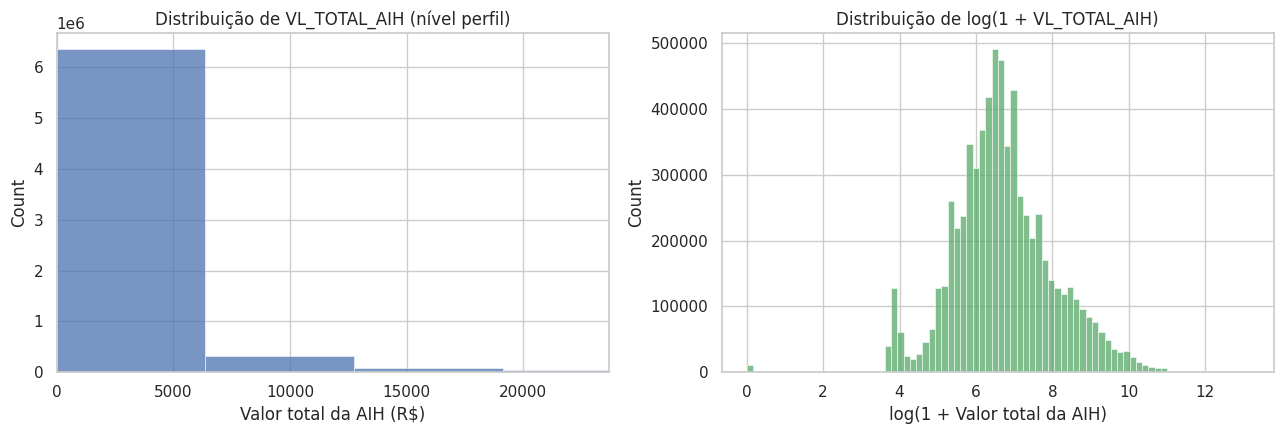

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["VL_TOTAL_AIH"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição de VL_TOTAL_AIH (nível perfil)")
axes[0].set_xlabel("Valor total da AIH (R$)")
axes[0].set_xlim(0, df["VL_TOTAL_AIH"].quantile(0.99))

sns.histplot(np.log1p(df["VL_TOTAL_AIH"]), bins=80, ax=axes[1], color="#55A868")
axes[1].set_title("Distribuição de log(1 + VL_TOTAL_AIH)")
axes[1].set_xlabel("log(1 + Valor total da AIH)")

plt.tight_layout()
plt.show()

for c in ["VL_TOTAL_AIH", "QT_DIAS_PERMANENCIA", "QT_INTERNACOES"]:
    s = df[c].astype("float64")
    print(f"{c:<22} skewness={s.skew():7.2f}   kurtosis={s.kurtosis():8.2f}")

As três variáveis somáveis de nível-perfil têm **assimetria positiva forte** (skewness entre 10 e 21) e **curtose muito alta** — nada perto de uma normal. Isso é esperado em dados de saúde/custos: a maioria dos atendimentos é "comum" (baixo valor, curta permanência), e uma cauda longa de casos graves/custosos distorce a distribuição. `log1p(VL_TOTAL_AIH)` aproxima bastante o formato de uma normal, o que é um indício útil para uma futura modelagem (ex.: usar `log(valor)` como alvo/insumo em vez do valor bruto).

IEP_RECALC         skewness= -1.87   kurtosis=  6.12
PC_ICSAP_RECALC    skewness=  1.08   kurtosis=  3.32


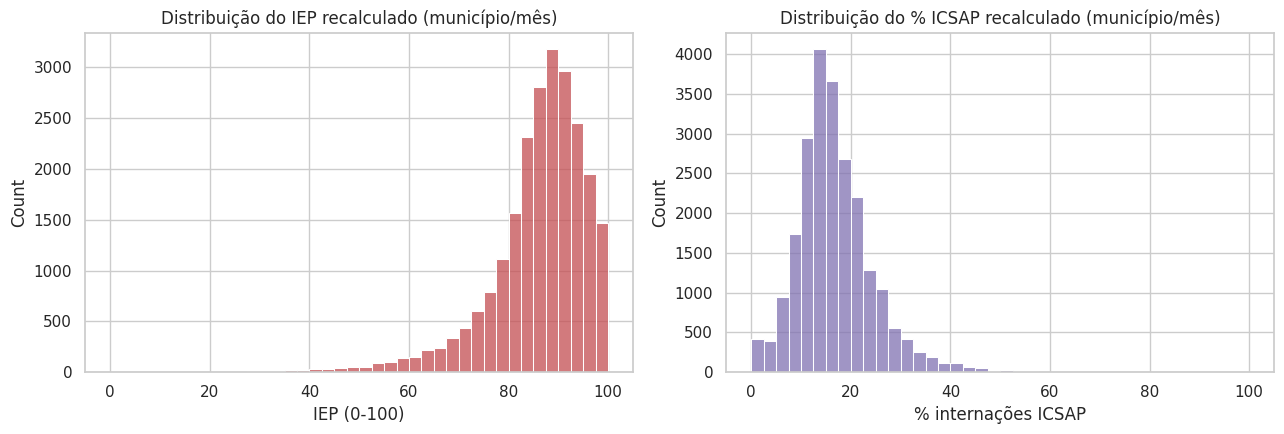

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(mun["IEP_RECALC"].dropna(), bins=40, ax=axes[0], color="#C44E52")
axes[0].set_title("Distribuição do IEP recalculado (município/mês)")
axes[0].set_xlabel("IEP (0-100)")

sns.histplot(mun["PC_ICSAP_RECALC"].dropna(), bins=40, ax=axes[1], color="#8172B2")
axes[1].set_title("Distribuição do % ICSAP recalculado (município/mês)")
axes[1].set_xlabel("% internações ICSAP")

plt.tight_layout()
plt.show()

for c in ["IEP_RECALC", "PC_ICSAP_RECALC"]:
    s = mun[c].dropna()
    print(f"{c:<18} skewness={s.skew():6.2f}   kurtosis={s.kurtosis():6.2f}")

In [12]:
# Teste de normalidade (Shapiro-Wilk exige amostra <= 5000; a base completa é grande demais)
amostra_valor = df["VL_TOTAL_AIH"].sample(5000, random_state=RANDOM_STATE)
stat, p = stats.shapiro(amostra_valor)
print(f"Shapiro-Wilk VL_TOTAL_AIH (amostra n=5000): estatística={stat:.4f}  p-valor={p:.2e}")

amostra_iep = mun["IEP_RECALC"].dropna().sample(min(5000, mun['IEP_RECALC'].notna().sum()), random_state=RANDOM_STATE)
stat2, p2 = stats.shapiro(amostra_iep)
print(f"Shapiro-Wilk IEP_RECALC (município/mês, amostra): estatística={stat2:.4f}  p-valor={p2:.2e}")

print("\nEm ambos os casos p << 0,05 -> rejeitamos a hipótese de normalidade. "
      "Nenhuma das variáveis analisadas segue uma distribuição normal; VL_TOTAL_AIH se aproxima de uma "
      "log-normal, coerente com o formato de custos em saúde.")

Shapiro-Wilk VL_TOTAL_AIH (amostra n=5000): estatística=0.2490  p-valor=3.44e-89
Shapiro-Wilk IEP_RECALC (município/mês, amostra): estatística=0.8706  p-valor=1.20e-53

Em ambos os casos p << 0,05 -> rejeitamos a hipótese de normalidade. Nenhuma das variáveis analisadas segue uma distribuição normal; VL_TOTAL_AIH se aproxima de uma log-normal, coerente com o formato de custos em saúde.


## 7. Valores faltantes (missing) e outliers

### 7.1 Valores ausentes

In [13]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Percentual de nulos por coluna (nível perfil):")
print(missing_pct.round(2))

print("\nCruzamento FL_ICSAP x nulo em ID_GRUPO_ICSAP (nulo deve ocorrer só quando FL_ICSAP=0):")
print(pd.crosstab(df["FL_ICSAP"], df["ID_GRUPO_ICSAP"].isna(), rownames=["FL_ICSAP"], colnames=["ID_GRUPO_ICSAP nulo"]))

Percentual de nulos por coluna (nível perfil):
ID_GRUPO_ICSAP                   85.05
NM_GRUPO_ICSAP                   85.05
PC_OBITOS_HOSPITAL_MES            0.10
PERMANENCIA_MEDIA_HOSPITAL_MES    0.10
dtype: float64

Cruzamento FL_ICSAP x nulo em ID_GRUPO_ICSAP (nulo deve ocorrer só quando FL_ICSAP=0):
ID_GRUPO_ICSAP nulo    False    True 
FL_ICSAP                             
0                          0  5843682
1                    1026889        0


- `ID_GRUPO_ICSAP` / `NM_GRUPO_ICSAP` estão nulos em **85,05%** das linhas, exatamente e apenas quando `FL_ICSAP = 0` (perfil de diagnóstico fora da lista ICSAP) — confirmado pelo cruzamento acima (0 casos fora do padrão esperado). **Não devem ser preenchidos com 0/"N/A" artificial**, pois representam ausência de classificação, não ausência de dado.
- `PERMANENCIA_MEDIA_HOSPITAL_MES` e `PC_OBITOS_HOSPITAL_MES` estão nulos em **0,10%** das linhas, e a contagem de combinações hospital/mês afetadas bate exatamente com as **243 combinações sem saída hospitalar registrada no mês** documentadas nas regras do grupo (ver seção 4) — nenhum preenchimento artificial deve ser feito aqui também.
- Nenhuma outra coluna somável apresenta nulos: a base está bem controlada nas variáveis-chave de contagem/valor.

### 7.2 Outliers

VL_TOTAL_AIH           limites IQR=[-1.654.56 ; 3.730.18]   outliers=893.663 (13.01%)   máximo observado=509.798.00
QT_DIAS_PERMANENCIA    limites IQR=[-8.00 ; 16.00]   outliers=615.755 (8.96%)   máximo observado=1.870.00


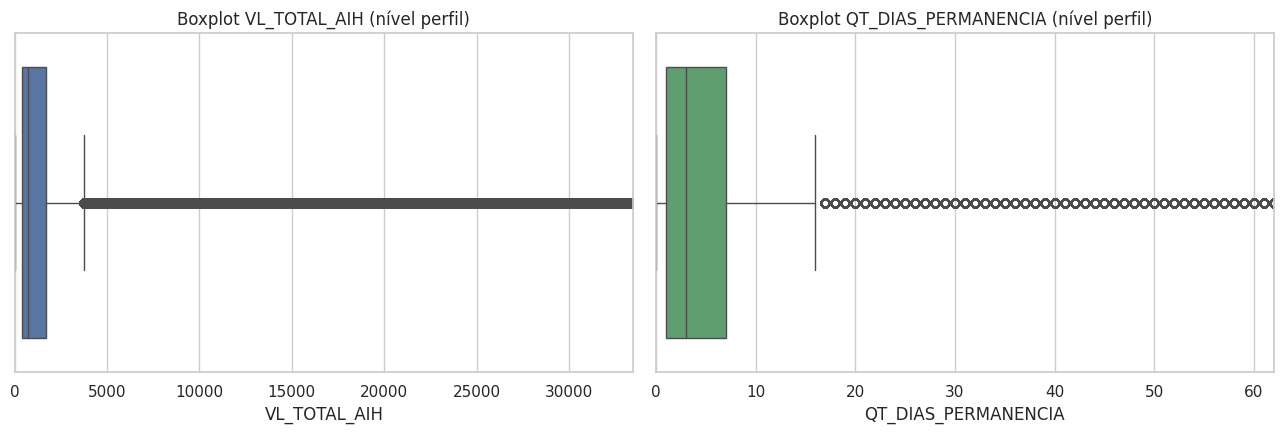

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=df["VL_TOTAL_AIH"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Boxplot VL_TOTAL_AIH (nível perfil)")
axes[0].set_xlim(0, df["VL_TOTAL_AIH"].quantile(0.995))

sns.boxplot(x=df["QT_DIAS_PERMANENCIA"], ax=axes[1], color="#55A868")
axes[1].set_title("Boxplot QT_DIAS_PERMANENCIA (nível perfil)")
axes[1].set_xlim(0, df["QT_DIAS_PERMANENCIA"].quantile(0.995))
plt.tight_layout()
plt.show()

for c in ["VL_TOTAL_AIH", "QT_DIAS_PERMANENCIA"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c:<22} limites IQR=[{lo:,.2f} ; {hi:,.2f}]   outliers={n_out:,} ({n_out/len(df)*100:.2f}%)   máximo observado={df[c].max():,.2f}".replace(",", "."))

In [15]:
# Caso extremo de permanência média hospitalar -> investigar antes de decidir tratamento
top_permanencia = hosp.sort_values("PERMANENCIA_MEDIA_RECALC", ascending=False).head(5)[
    ["DT_COMPETENCIA", "NM_ESTABELECIMENTO", "TP_ESTABELECIMENTO",
     "QT_DIAS_PERMANENCIA", "QT_SAIDAS_HOSPITALARES", "PERMANENCIA_MEDIA_RECALC"]
]
top_permanencia

,DT_COMPETENCIA,NM_ESTABELECIMENTO,TP_ESTABELECIMENTO,QT_DIAS_PERMANENCIA,QT_SAIDAS_HOSPITALARES,PERMANENCIA_MEDIA_RECALC
9068,2024-03-01,CASAS ANDRE LUIZ GUARULHOS,HOSPITAL ESPECIALIZADO,16074,1,"16,074.00"
7218,2023-12-01,CASAS ANDRE LUIZ GUARULHOS,HOSPITAL ESPECIALIZADO,15988,1,"15,988.00"
5378,2023-09-01,CASAS ANDRE LUIZ GUARULHOS,HOSPITAL ESPECIALIZADO,15546,1,"15,546.00"
10926,2024-06-01,CASAS ANDRE LUIZ GUARULHOS,HOSPITAL ESPECIALIZADO,15260,1,"15,260.00"
13544,2024-10-01,CASA DE DAVID SAO PAULO,HOSPITAL ESPECIALIZADO,8920,1,"8,920.00"


**Decisão sobre outliers (justificativa):** pelo método IQR, cerca de **13,0%** das linhas de `VL_TOTAL_AIH` e **9,0%** de `QT_DIAS_PERMANENCIA` seriam sinalizadas como outlier — um volume alto demais para simplesmente descartar. Investigando o caso mais extremo de `PERMANENCIA_MEDIA_HOSPITAL_MES` (acima de 16.000 dias), encontramos que ele pertence a um **HOSPITAL ESPECIALIZADO** (ex.: "CASAS ANDRE LUIZ GUARULHOS") com apenas 1 saída registrada no mês e permanência acumulada de milhares de dias — típico de instituições de cuidado psiquiátrico/crônico de longuíssima permanência, e **não um erro de digitação**.

Por isso, a estratégia do grupo é:
- **Não remover** outliers de `VL_TOTAL_AIH` e `QT_DIAS_PERMANENCIA` no nível-perfil — eles refletem a própria natureza assimétrica de custos e permanência em saúde;
- **Segmentar por `TP_ESTABELECIMENTO`** antes de comparar hospitais entre si (um hospital geral não deve ser comparado diretamente com um hospital especializado de longa permanência);
- Para uma futura modelagem preditiva, considerar transformação logarítmica de `VL_TOTAL_AIH`/`QT_DIAS_PERMANENCIA` e, se necessário, tratar separadamente o pequeno grupo de estabelecimentos especializados como um segmento à parte (não como ruído a ser eliminado).

## 8. Relações entre variáveis (sempre no grão correto)

Correlacionamos apenas depois de agrupar/deduplicar no mesmo nível (regra 17 do grupo) — nunca cruzando indicadores de município/mês ou hospital/mês repetidos em milhões de linhas do nível-perfil.

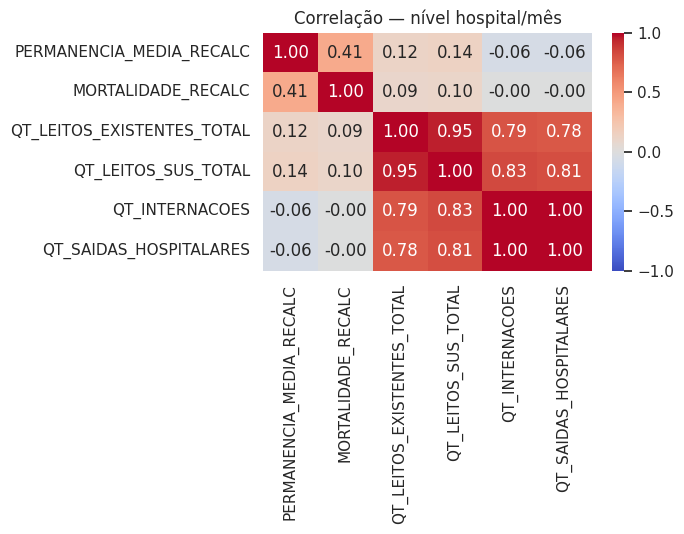

In [16]:
corr_cols_hosp = [
    "PERMANENCIA_MEDIA_RECALC", "MORTALIDADE_RECALC",
    "QT_LEITOS_EXISTENTES_TOTAL", "QT_LEITOS_SUS_TOTAL",
    "QT_INTERNACOES", "QT_SAIDAS_HOSPITALARES",
]
corr_hosp = hosp[corr_cols_hosp].corr(numeric_only=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_hosp, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlação — nível hospital/mês")
plt.tight_layout()
plt.show()

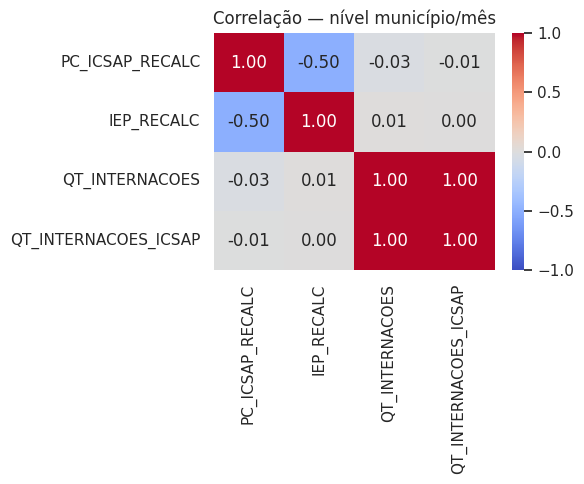

In [17]:
corr_cols_mun = ["PC_ICSAP_RECALC", "IEP_RECALC", "QT_INTERNACOES", "QT_INTERNACOES_ICSAP"]
corr_mun = mun[corr_cols_mun].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_mun, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlação — nível município/mês")
plt.tight_layout()
plt.show()

**Leituras (associação, não causa):**
- `QT_LEITOS_EXISTENTES_TOTAL` e `QT_LEITOS_SUS_TOTAL` são fortemente correlacionados entre si (0,95) e com o volume de internações/saídas do hospital (≈0,78–0,83) — hospitais maiores atendem mais e têm mais leitos, como esperado estruturalmente.
- `PERMANENCIA_MEDIA_RECALC` e `MORTALIDADE_RECALC` têm correlação moderada-positiva (0,41): hospitais com maior permanência média tendem a registrar mortalidade mais alta — plausível (casos mais graves ficam internados por mais tempo *e* têm maior risco de óbito), mas **isso não prova que a permanência causa a mortalidade** (pode ser um efeito da gravidade do caso, um fator de confusão comum a ambas as variáveis).
- No nível município/mês, `IEP_RECALC` e `PC_ICSAP_RECALC` têm correlação negativa moderada (-0,50): municípios com maior participação de ICSAP no valor elegível tendem a ter IEP mais baixo — o que é **consistente com a própria fórmula do IEP** (o indicador é definido como o complemento do peso das ICSAP), então essa correlação é em parte estrutural/matemática e não deve ser lida como um achado causal isolado.
- Volume de internações (`QT_INTERNACOES`) não mostra correlação relevante com `IEP_RECALC` ou `PC_ICSAP_RECALC` (|r| < 0,05) — municípios não apresentam, nestes dados, relação linear clara entre "quanto internam" e "quão bem cuidada é a atenção primária".

Reforçando a regra 18 do grupo: **estes são dados administrativos e observacionais** — nenhuma das correlações acima deve ser apresentada como relação de causa e efeito.

## 9. Conclusão da AED e implicações para a modelagem

**Principais achados:**

1. **Grão dos dados é o maior risco de erro.** Confirmamos que `len(df)` ≈ 6,87 milhões não é o número de internações; o número correto de internações é `QT_INTERNACOES.sum()` ≈ 8,25 milhões, e a checagem `internações + continuidades = registros de AIH` bateu exatamente, validando a integridade da base.
2. **Indicadores pré-calculados (IEP, % ICSAP, permanência média/mortalidade hospitalar, leitos) são constantes dentro de município/mês ou hospital/mês.** Recalculamos todos a partir da soma dos perfis e a diferença frente aos valores fornecidos foi desprezível (< 0,01 na média), o que **valida tanto a qualidade da base quanto a corretude do pipeline de agregação do grupo**.
3. **Nenhuma variável somável segue distribuição normal** — todas apresentam assimetria positiva forte (skew > 10 no nível-perfil), típica de dados de custo/tempo de internação em saúde. `log1p(VL_TOTAL_AIH)` é a transformação recomendada para uso futuro em modelos lineares/estatísticos.
4. **Valores nulos são, em sua totalidade, nulos "corretos e esperados"** (ICSAP não classificado, hospital sem saída no mês) — não há evidência de dados faltando por problema de qualidade/captura, então **não é necessário nenhum processo de imputação** nesta fase.
5. **Outliers refletem heterogeneidade real do sistema de saúde (hospitais gerais x especializados), não erro de digitação** — a estratégia recomendada é segmentar por `TP_ESTABELECIMENTO` em vez de remover os extremos.
6. **As correlações identificadas são moderadas e coerentes com a definição dos próprios indicadores** (ex.: IEP x % ICSAP), reforçando que qualquer leitura de causalidade deve ser evitada — os dados são observacionais.

**Implicações para a próxima etapa (modelagem preditiva):**
- A base é **viável** para modelagem, desde que as agregações sejam feitas no grão correto (perfil, município/mês ou hospital/mês conforme o objetivo).
- Recomenda-se usar `log(VL_TOTAL_AIH)` e possivelmente `log(QT_DIAS_PERMANENCIA + 1)` como variáveis-alvo/insumo para reduzir o efeito da assimetria.
- `TP_ESTABELECIMENTO` deve entrar como covariável/segmento em qualquer modelo hospitalar, dado seu papel na explicação dos outliers de permanência.
- Como todas as fontes cobrem apenas o estado de **SP**, ao longo de **36 meses (jan/2023–dez/2025)**, qualquer modelo treinado nesta base deve ter sua generalização para outras UFs tratada como limitação explícita.
- Os nulos legítimos de ICSAP e de indicadores hospitalares devem ser tratados como **categoria própria** (ex.: "não classificado" / "sem saída no mês") em modelos de árvore, e não descartados nem imputados com zero.